In [4]:
import matplotlib.pyplot as plt
import numpy as np
import bilby
from bilby.gw.conversion import solar_mass
from bilby.gw.utils import lalsim_SimNeutronStarMaximumMass, lalsim_SimNeutronStarFamMinimumMass
from bilby.gw.conversion import lambda_from_mass_and_family
from converse_likelihood import _build_family


In [11]:
# ---------- config ----------
N_PPD_SAMPLES = 50      # posterior draws to plot
N_MASS_POINTS = 200      # resolution of each λ(m) curve
M_PLOT_MIN    = 1.0      # M☉
M_PLOT_MAX    = 2.0
m_plot        = np.linspace(M_PLOT_MIN, M_PLOT_MAX, N_MASS_POINTS)

log10_p1_cgs  = 35.293288373856534
log10_p2_cgs  = 35.648689969687915
causal        = False

# injection truth
param1_true = 4.183994058757201
param2_true = 3.168076721819637
param3_true = 1.300271383168368
# ----------------------------

result   = bilby.core.result.read_in_result(filename="outdir/eos_hierarchical_result.pkl")
posterior = result.posterior

/var/folders/t6/9g0339bj7fjdlm1vw31kx_tc0000gn/T/ipykernel_82414/49351416.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


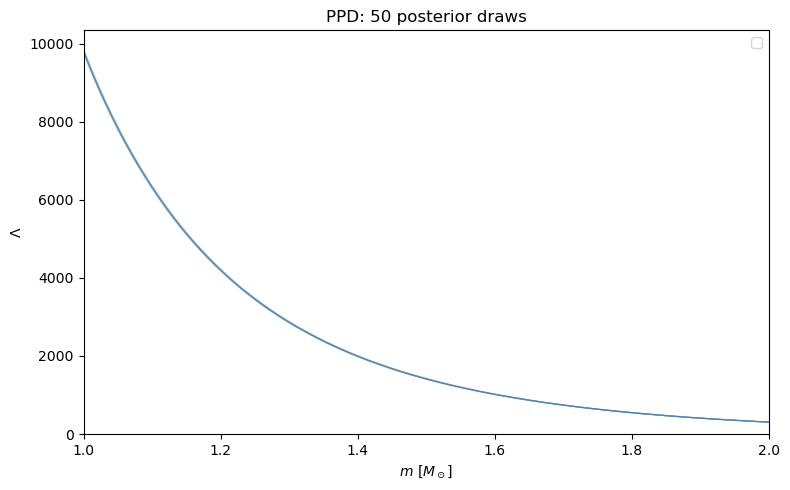

In [ ]:
# Draw N_PPD_SAMPLES rows from the posterior
draws = posterior.sample(N_PPD_SAMPLES, replace=True)[["param1", "param2", "param3"]]

fig, ax = plt.subplots(figsize=(8, 5))

for _, row in draws.iterrows():
    family = _build_family(row.param1, log10_p1_cgs, row.param2, log10_p2_cgs, row.param3, int(causal))
    if family is None:
        continue

    m_min = lalsim_SimNeutronStarFamMinimumMass(family) / solar_mass
    m_max = lalsim_SimNeutronStarMaximumMass(family) / solar_mass

    # Only plot over masses the EOS supports
    m_valid = m_plot[(m_plot >= m_min) & (m_plot <= m_max)]
    if len(m_valid) == 0:
        continue

    lam = np.array([lambda_from_mass_and_family(m, family) for m in m_valid])
    ax.plot(m_valid, lam, color="steelblue", alpha=0.05, lw=0.8)

# Overplot injection truth
family_true = _build_family(param1_true, log10_p1_cgs, param2_true, log10_p2_cgs, param3_true, int(causal))
m_min_true  = lalsim_SimNeutronStarFamMinimumMass(family_true) / solar_mass
m_max_true  = lalsim_SimNeutronStarMaximumMass(family_true) / solar_mass
m_true      = m_plot[(m_plot >= m_min_true) & (m_plot <= m_max_true)]
lam_true    = np.array([lambda_from_mass_and_family(m, family_true) for m in m_true])
# ax.plot(m_true, lam_true, color="crimson", lw=2, label="Injection truth")

ax.set_xlabel(r"$m\ [M_\odot]$")
ax.set_ylabel(r"$\Lambda$")
ax.set_xlim(M_PLOT_MIN, M_PLOT_MAX)
ax.set_ylim(bottom=0)
ax.legend()
ax.set_title(f"PPD: {N_PPD_SAMPLES} posterior draws")
plt.tight_layout()
# plt.savefig("outdir/ppd_mass_lambda.png", dpi=150)
plt.show()
